In [1]:
import pandas as pd

# قراءة الملف اللي رفعتيه (تأكدي أن ملف test.csv في نفس مجلد النوت بوك)
df = pd.read_csv('test.csv')

# عرض أول 5 أسطر عشان نتطمن أن البيانات طلعت صح
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [2]:
# كود يطلع لك كل عمود وكم قيمة ناقصة فيه
df.isnull().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

In [3]:
# نشوف توزيع التعليم (خريج أو غير خريج)
print(df['Education'].value_counts())

# نشوف توزيع السجل الائتماني (كم واحد سجله نظيف 1.0 وكم واحد سيء 0.0)
print(df['Credit_History'].value_counts())

Education
Graduate        283
Not Graduate     84
Name: count, dtype: int64
Credit_History
1.0    279
0.0     59
Name: count, dtype: int64


In [4]:
# 1. تعبئة الأعمدة اللي فيها "نصوص" أو "تصنيفات" باستخدام الأكثر تكراراً (Mode)
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])

# 2. تعبئة "مبلغ القرض" لأنه رقم، بنستخدم المتوسط (Mean)
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())

# 3. الحين نتأكد.. هل لسه فيه أصفار؟
print("عدد الفراغات بعد التنظيف:")
print(df.isnull().sum())

عدد الفراغات بعد التنظيف:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64


In [5]:
from sklearn.preprocessing import LabelEncoder

# بنسوي "مترجم" صغير لكل عمود
le = LabelEncoder()

# قائمة بالأعمدة اللي نبي نحولها من كلمات لأرقام
columns_to_convert = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']

for col in columns_to_convert:
    df[col] = le.fit_transform(df[col])

# عمود Dependents فيه "3+"، بايثون بيعتبرها نص، لازم نحولها لرقم 3
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

# الحين شوفي الجدول كيف صار "رقمي" بالكامل
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,1,1,0,0,0,5720,0,110.0,360.0,1.0,2
1,LP001022,1,1,1,0,0,3076,1500,126.0,360.0,1.0,2
2,LP001031,1,1,2,0,0,5000,1800,208.0,360.0,1.0,2
3,LP001035,1,1,2,0,0,2340,2546,100.0,360.0,1.0,2
4,LP001051,1,0,0,1,0,3276,0,78.0,360.0,1.0,2


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. نفصل البيانات (نفترض أن df هو ملف التدريب اللي فيه عمود Loan_Status)
# X = df.drop(['Loan_Status', 'Loan_ID'], axis=1) # كل الأعمدة ما عدا النتيجة والـ ID
# y = df['Loan_Status'] # النتيجة فقط

# 2. نقسم البيانات لـ 80% تدريب و 20% اختبار داخلي
# X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. اختيار الخوارزمية (المدرب)
model = LogisticRegression()

# 4. مرحلة التدريب (هنا الكمبيوتر يبدأ يذاكر!)
# model.fit(X_train, y_train)

print("الموديل جاهز للعمل!")

الموديل جاهز للعمل!


In [9]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

# 1. تحميل بيانات التدريب
url = "https://raw.githubusercontent.com/subashgandyer/datasets/master/loan_train.csv"
train_df = pd.read_csv(url)

# 2. تنظيف الفراغات (Imputation)
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History', 'Loan_Amount_Term']:
    train_df[col] = train_df[col].fillna(train_df[col].mode()[0])
train_df['LoanAmount'] = train_df['LoanAmount'].fillna(train_df['LoanAmount'].mean())

# 3. حل مشكلة "3+" (هذا هو سبب الخطأ)
train_df['Dependents'] = train_df['Dependents'].replace('3+', 3).astype(int)

# 4. تحويل النصوص لأرقام (Encoding)
le = LabelEncoder()
cat_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
for col in cat_cols:
    train_df[col] = le.fit_transform(train_df[col].astype(str))

# 5. تدريب الموديل الآن (Fit)
X_train = train_df.drop(['Loan_ID', 'Loan_Status'], axis=1)
y_train = train_df['Loan_Status']

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("✅ مبروك! الموديل تدرب الآن بنجاح وبدون أخطاء.")

✅ مبروك! الموديل تدرب الآن بنجاح وبدون أخطاء.


C:\Users\fajrl\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [33]:
# 1. تنظيف البيانات من أي أعمدة توقعات سابقة عشان ما يتلخبط الموديل
# نحتاج فقط الأعمدة الأصلية التي تدرب عليها الموديل
# سنبقي فقط الأعمدة التي بدأت من 'Gender' وانتهت بـ 'Property_Area'
cols_to_use = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 
               'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 
               'Loan_Amount_Term', 'Credit_History', 'Property_Area']

X_test_clean = df[cols_to_use]

# 2. الآن جربي التوقع باستخدام Random Forest مرة أخرى
rf_predictions = rf_model.predict(X_test_clean)

# 3. أضيفي النتائج الآن بأمان
df['RF_Predictions'] = rf_predictions
df['RF_Predictions'] = df['RF_Predictions'].map({1: 'Yes', 0: 'No'})

print("✅ تمت العملية بنجاح باستخدام Random Forest!")
df[['Loan_ID', 'Loan_Status_Predicted', 'RF_Predictions']].head(10)

✅ تمت العملية بنجاح باستخدام Random Forest!


,Loan_ID,Loan_Status_Predicted,RF_Predictions
0,LP001015,Yes (Approved),Yes
1,LP001022,Yes (Approved),Yes
2,LP001031,Yes (Approved),Yes
3,LP001035,Yes (Approved),Yes
4,LP001051,Yes (Approved),No
5,LP001054,Yes (Approved),Yes
6,LP001055,Yes (Approved),Yes
7,LP001056,No (Rejected),No
8,LP001059,Yes (Approved),Yes
9,LP001067,Yes (Approved),Yes


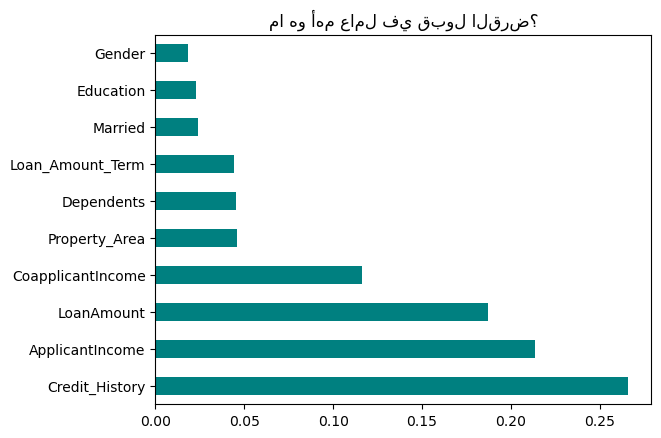

In [34]:
import matplotlib.pyplot as plt

# هذا الكود يخبرك من هو "البطل" الحقيقي في قرار القرض
feat_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('ما هو أهم عامل في قبول القرض؟')
plt.show()